# Implementación del modelo descrito en el paper: Bearing Fault Detection Scheme Using Machine Learning for Condition Monitoring Applications

Puede encontrar el enlace al paper en el siguiente [vínculo](https://www.diva-portal.org/smash/get/diva2:1793876/FULLTEXT01.pdf)

En trabajo adjunto se describe una red neuronal convolucional (CNN por sus siglas en inglés) para detectar fallas en pistas internas y externas en rodamientos. El objetivo de este notebook es implementar de la arquitectura descrita en el paper para corroborar los resultados con un conjunto de datos distinto.



### Conjunto de datos
El conjunto de datos fue creado por el centro para sistemas de matenimiento inteligentes (IMS por sus siglas en ingles) con ayuda de la corporación Rexnord en Milwakee. El paquete de datos incluye 3 conjuntos de archivos, cada conjunto posee capturas de señales de vibración de 1 segundo, registradas en intervalos específicos. Cada archivo contiene 20.480 puntos, con una frecuencia de muestreo de 20 kHz. El nombre del archivo indica cuándo se recogieron los datos. Existen saltos entre estampas de tiempo que indican un cese de mediciones por termino del horario laboral.

Para esta prueba solo se empleara el conjunto de datos 1 que posee los siguientes detalles:
- Las mediciones se obtuvieron de 8 sensores distribuidos en 4 rodamientos.
- El intervalo de grabación fue de 10 minutos. A excepción de los primeros 43 archivos que fueron capturados cada 5 minutos.
- Al final del experimento de prueba hasta fallo, ocurrió un defecto en la pista interior del rodamiento 3 y un defecto en el elemento rodante del rodamiento 4.



### Preprocesamiento de los datos
El preprocesamiento de los datos consiste en los siguientes pasos:

1. Tomar los datos de señales correspondiente a un determinado tiempo y extraer sus componentes frecuenciales usando la transformada de Wavelet Continua.
2. Una vez que se obtiene la información de la amplitud de las frecuencias se transforman a una escalograma de tamaño 227×227×3.
3. Se cargan las imágenes con una correspondiente etiqueta indicando el fallo al que representan. las etiquetas son:
  * IRF: inner race fault o falla de pista interna
  * ORF: outer race fault o falla de pista externa
  * NF: Normal frecuency

### Arquitectura y entrenamiento del modelo
El modelo empleado es una red SqueezeNet preentrenada a la cual se le hicieron los siguientes cambios indicados en el trabajo:

* El modelo toma como entrada las imágenes de escalogramas CWT etiquetadas y devuelve la etiqueta de clase predicha del estado del rodamiento junto con las probabilidades correspondientes a cada clase.

* La última capa entrenable y la capa final son reemplazadas por una nueva capa convolucional 2D y una nueva capa de clasificación, con el fin de reentrenar SqueezeNet usando imágenes de escalogramas y adaptarlo a las nuevas clases objetivo.

* La nueva capa convolucional tiene tres filtros de tamaño 1×1, correspondientes a las tres clases de salida.

* Los factores de tasa de aprendizaje para pesos y sesgos se establecen en 10.

* El modelo utiliza el optimizador de descenso de gradiente estocástico con momento (SGDM or sus siglas en inglés) para lograr la convergencia.

* Para el entrenamiento se usó la técnica de validación cruzada.


## Carga de los datos



In [ ]:
import pywt
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np
import glob
import gdown



In [ ]:
# Descarga del dataset subido a google drive
IMS_dataset_path = 'datos/IMS_bearing_dataset'

if os.path.exists(IMS_dataset_path):
    print("El dataset ya se encuentra descargado.")
else:
    print("Descargando el dataset...")
    try:
        import gdown
    except ImportError:
        !pip install gdown

    # https://drive.google.com/file/d/10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD/view?usp=drive_link
    file_id = "10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD"
    !gdown --id {file_id} -O NASA_IMS_bearing_dataset.zip


    !mkdir -p datos/IMS_bearing_dataset
    print(f"descomprimiendo el daset en {IMS_dataset_path}...")
    !unzip NASA_IMS_bearing_dataset.zip -d {IMS_dataset_path} >> /dev/null
    !rm NASA_IMS_bearing_dataset.zip
    print("Dataset descargado y descomprimido correctamente.")

Descargando el dataset...
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD
From (redirected): https://drive.google.com/uc?id=10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD&confirm=t&uuid=39e209d1-7518-4fff-a4ea-9149743ef4b9
To: /home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/NASA_IMS_bearing_dataset.zip
100%|██████████████████████████████████████| 1.67G/1.67G [01:12<00:00, 23.1MB/s]


In [19]:
def load_ims_data(path):
    """
    Carga y concatena archivos de texto que contienen datos de señales de vibración del dataset IMS.

    Esta función busca todos los archivos en el directorio especificado, los ordena alfabéticamente,
    los carga como arrays NumPy y los agrupa en un solo arreglo de tamaño n, siendo n la cantidad de archivos.

    Parámetros:
    -----------
    path : str
        Ruta al directorio que contiene los archivos de texto (.txt) con las señales.

    Retorna:
    --------
    np.ndarray
        Arreglo de NumPy de una dimensión con todos los archivos cargados.
        Cada fila representa un archivo, y se espera que cada uno contenga 20480
        mediciones de los sensores.

    Ejemplo:
    --------
    >>> data = load_ims_data('/ruta/al/dataset')
    >>> data.shape
    (n_archivos, 20480)
    """
    files = sorted(glob.glob(path + '/*'))
    data = [np.loadtxt(f) for f in files]
    return np.array(data)

signals = load_ims_data('datos/IMS_bearing_dataset/1st_test/1st_test/')
signals

array([[[-0.022, -0.039, -0.183, ..., -0.134, -0.129, -0.142],
        [-0.105, -0.017, -0.164, ...,  0.029, -0.115, -0.122],
        [-0.183, -0.098, -0.195, ..., -0.007, -0.171, -0.071],
        ...,
        [-0.193, -0.303, -0.071, ..., -0.251, -0.151,  0.007],
        [-0.115,  0.076, -0.078, ..., -0.002, -0.151, -0.005],
        [-0.042,  0.098,  0.103, ..., -0.342, -0.095, -0.276]],

       [[-0.117, -0.076, -0.127, ..., -0.002, -0.098, -0.051],
        [-0.132, -0.068, -0.117, ..., -0.076, -0.117, -0.085],
        [-0.186, -0.12 , -0.217, ..., -0.112, -0.132, -0.054],
        ...,
        [-0.134, -0.081, -0.217, ..., -0.107, -0.027, -0.173],
        [-0.212, -0.02 , -0.166, ..., -0.117, -0.068, -0.068],
        [-0.208, -0.073, -0.203, ..., -0.068, -0.12 , -0.059]],

       [[-0.054, -0.049, -0.208, ..., -0.222, -0.085, -0.129],
        [-0.215, -0.044, -0.151, ..., -0.142, -0.059, -0.146],
        [-0.242, -0.112, -0.081, ..., -0.103, -0.137, -0.078],
        ...,
        [-0.

In [ ]:
def generate_cwt_images(signals, output_dir):
    """
    Genera imágenes (escalogramas) de transformada wavelet continua (CWT) a partir de señales multicanal y las guarda como PNG.

    Para cada conjunto de señales, se aplica la CWT a cada canal individual (columna), generando un espectrograma tipo scalogram.
    Las imágenes generadas se guardan en el directorio especificado.

    Parámetros:
    -----------
    signals : np.ndarray
        Arreglo de señales de forma (n_muestras, m_mediciones, z_canales), donde:
        - n_muestras es el número de archivos de señal,
        - m_mediciones es la longitud de cada señal temporal,
        - z_canales es el número de canales (e.g., rodamientos).

    output_dir : str
        Ruta al directorio donde se guardarán las imágenes PNG generadas.

    Salida:
    -------
    No retorna nada. Las imágenes generadas se guardan con nombres del tipo:
    'cwt_<índice_muestra>_bearing_<índice_canal>.png'.

    Ejemplo:
    --------
    >>> generate_cwt_images(signals[:10], 'scalograms')
    # Genera imágenes CWT para los primeros 100 archivos de señal en el directorio 'scalograms'
    """
    os.makedirs(output_dir, exist_ok=True)
    for i, signal_set in enumerate(signals):
        for j in range(signal_set.shape[1]):
            signal = signal_set[:, j]
            coef, freqs = pywt.cwt(signal, scales=np.arange(1, 129), wavelet='morl')
            plt.imshow(np.abs(coef), cmap='jet', aspect='auto')
            plt.axis('off')
            plt.savefig(f"{output_dir}/cwt_{i}_bearing_{j}.png", bbox_inches='tight', pad_inches=0)
            plt.close()


In [23]:
# Nota esta funcion puede requerir mucha memoria ram, por lo que para esta prueba
# solo se emplearon los 10 últimos archivos
total_files = 2156
n_archivos_deseados=50
signals_deseados = signals[:total_files-n_archivos_deseados:-1]

generate_cwt_images(signals_deseados, 'datos/scalograms')

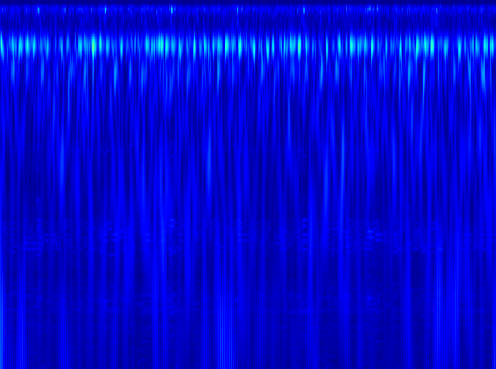

In [25]:
# Muestra del escalograma creado con el primer archivo del experimento 1st
from IPython.display import Image, display
display(Image('datos/scalograms/cwt_0_bearing_0.png'))

In [ ]:
# Bloque de codigo para separar los escalogramas según las etiquetas.
# Para este ejemplo se empleó el experimento 1st. Al final de este
# experimento se observaron fallas en la pista interna (IRF) del
# rodamiento 3 y fallas en la pista externa del rodaminento 4

import os
import shutil

# Definir carpetas
input_dir = 'datos/scalograms'  # donde se guardaron los .png
output_dataset_dir = 'datos/dataset_scalograms'    # destino organizado por clase

# Crear carpetas de salida
for cls in ['IRF', 'ORF', 'NF']:
    os.makedirs(os.path.join(output_dataset_dir, cls), exist_ok=True)

# Número de archivos totales en el test 1 (según Readme: 2156)
total_files = 2156

for file_idx in range(total_files):
    for ch in range(0, 8):  # 8 canales por archivo
        img_name = f'cwt_{file_idx}_bearing_{ch}.png'
        src_path = os.path.join(input_dir, img_name)

        if not os.path.exists(src_path):
            continue

        if file_idx < 40 and False: # NOTA: se niega esta parte ya que se tomaron los 10 ultimos archivos
            label = 'NF'
        else:
            if ch in [4, 5]:      # Rodamiento 3
                label = 'IRF'     # Falla en pista interior
            elif ch in [6, 7]:    # Rodamiento 4
                label = 'ORF'     # Falla en elemento rodante
            else:
                label = 'NF'      # Rodamientos 1 y 2

        dst_path = os.path.join(output_dataset_dir, label, img_name)
        shutil.copy(src_path, dst_path)


In [31]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.models import squeezenet1_1

transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
])

dataset = ImageFolder(output_dataset_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

model = squeezenet1_1(pretrained=True)
model.classifier[1] = nn.Conv2d(512, 3, kernel_size=(1,1))
model.num_classes = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /home/marck/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth
100%|██████████| 4.73M/4.73M [00:00<00:00, 6.18MB/s]


In [32]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

for epoch in range(10):
    model.train()
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)



        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")


Epoch 1: Loss = 1.0751
Epoch 2: Loss = 1.0988
Epoch 3: Loss = 1.0994
Epoch 4: Loss = 1.0967
Epoch 5: Loss = 0.6785
Epoch 6: Loss = 0.5490
Epoch 7: Loss = 0.6866
Epoch 8: Loss = 0.5070
Epoch 9: Loss = 0.5808
Epoch 10: Loss = 0.3441


In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=dataset.classes))


[[ 86  12   0]
 [  0 196   0]
 [ 93   5   0]]
              precision    recall  f1-score   support

         IRF       0.48      0.88      0.62        98
          NF       0.92      1.00      0.96       196
         ORF       0.00      0.00      0.00        98

    accuracy                           0.72       392
   macro avg       0.47      0.63      0.53       392
weighted avg       0.58      0.72      0.63       392



/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels w